# 1D CNN 으로 DNA 서열 분류하기 — CNN 입문 실습

이번 실습에서는 **CNN(합성곱 신경망)** 을 사용해 DNA 서열(A/C/G/T/N 문자열)을 **1D CNN** 으로 분류함.


> **CNN을 아주 짧게 비유하면?**  
> DNA 서열을 처음부터 끝까지 훑으면서, "이런 패턴(예: `TATAAA`)이 보이는가?" 를
> 찾아내는 **작은 돋보기(필터)**를 사용한 것.  
> 그 돋보기들이 찾아낸 패턴들을 종합해서 0/1/2 중 어떤 클래스인지 맞힘.
>
> **k-mer** 가 "사람이 정한 단어 사전" 이라면,
> **Conv1D 필터는 데이터로부터 '단어(모티프)' 자체를 학습** 하는 모티프 검출기임.

순서:
1. 데이터를 숫자로 바꾸기 (**원-핫 인코딩**)
2. **1D CNN** 모델 만들기
3. 학습시키기
4. 예측하고 리더보드에 제출하기


> ## ⚡ Colab 사용법 (먼저 읽어주세요)
>
> 1. 상단 메뉴 **런타임 → 런타임 유형 변경 → 하드웨어 가속기: GPU (T4)** 선택 후 저장하면 학습이 훨씬 빨라집니다.
> 2. 셀을 **위에서부터 차례대로** ▶ 실행하세요 (`Shift + Enter`).
> 3. **`▶️ [실행만 하세요]`** 라고 적힌 회색 칸은 **코드를 볼 필요 없이 실행만** 하면 됩니다. (코드를 보고 싶으면 그 칸을 더블클릭)


## 0. 시작 전 준비

1. https://agtech.pythonanywhere.com/ 에 접속하여 회원가입할 것.
(비밀번호는 단순하게 권장. 예: 1234)
2. `username` 에 이메일 형식의 아이디를 기입할 것.
3. `password` 에 비밀번호를 기입할 것.

In [1]:
project = "dnasequence"  # 수정하지 마세요
username = ""  # 회원가입 시 사용한 이메일아이디 (예시. abc@hello.com)
password = ""  # 회원가입 시 정한 비밀번호를 입력하세요

리더보드 제출을 위한 기본 설정.  
아래 코드를 실행할 것.

In [2]:
import os
import urllib.request

if not os.path.exists("competition.py"):
    url = "https://raw.githubusercontent.com/agtechresearch/LectureMLbasic/refs/heads/main/competition/competition.py"
    filename = "competition.py"
    urllib.request.urlretrieve(url, filename)

아래 코드를 실행하여 데이터를 다운로드 받음: 3개의 csv 파일이 data 폴더에 다운로드됨

 * dataset.csv: 과거 인간 게놈에서 수집된 DNA 서열과 조절 영역 라벨(0/1/2) → 학습에 사용할 데이터셋 (50,000행)
 * problem.csv: 현재 분류 대상이 되는 10,000건의 DNA 서열 → ML 모델에 의하여 예측(0/1/2)을 수행하여야 할 데이터셋
 * submission.csv: 리더보드 서버 제출을 위한 파일 형식

In [3]:
import competition

# 파일 다운로드 (GitHub raw)
competition.download_competition_files(
    "https://raw.githubusercontent.com/agtechresearch/LectureMLbasic/main/dnasequence/bundle.zip",
    use_competition_url=False,
)

100%|██████████| 8.45M/8.45M [00:00<00:00, 46.9MiB/s]


----------
## 1. 데이터 불러오기 & 살펴보기

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

DATA_DIR = "data"

# 학습용 데이터 (dataset.csv) 와 예측할 문제 데이터 (problem.csv)
dataset = pd.read_csv(os.path.join(DATA_DIR, "dataset.csv"))
problemset = pd.read_csv(os.path.join(DATA_DIR, "problem.csv"))

dataset.head()

,seq,label
0,CAGTAGTGACAGATGCTGGCCCACCCCNAGGTCAGGATGACTCAGC...,0
1,TACATTTTTTTCAGCACCNCACCACACCTATTCCNAAATTGACTAC...,2
2,GCTCTGTATTAATNANACAATCTCAATGGNNGAGCTCCATAAAANA...,2
3,AAGATGTTTGCAAACTGATAAATGGTTACNTCATTAGAAATGTCCT...,0
4,CTGAGNTGGNAGAATCGAGGCATCCTAACATTAAAACGTGGCTGAT...,0


### 데이터 구성

* `seq` : DNA 서열 문자열.
알파벳은 `A / C / G / T / N` 5종, 길이는 **가변**.
  * `A`, `C`, `G`, `T` : 4종의 염기(base)
  * `N` : unknown base (약 5%)
* `label` : 조절 영역 클래스 (0 / 1 / 2).
원본 클래스명은 `enhancer` / `promoter` / `OCR`.

**목표**: `problem.csv` 의 10,000건에 대해 `label`(0/1/2)을 예측하여 제출.

클래스 분포:
label
0    16411
1    18481
2    15108
Name: count, dtype: int64

서열 길이 통계:
count    50000.000000
mean       429.891240
std        184.137082
min         87.000000
25%        236.000000
50%        401.000000
75%        600.000000
max        802.000000
Name: seq, dtype: float64


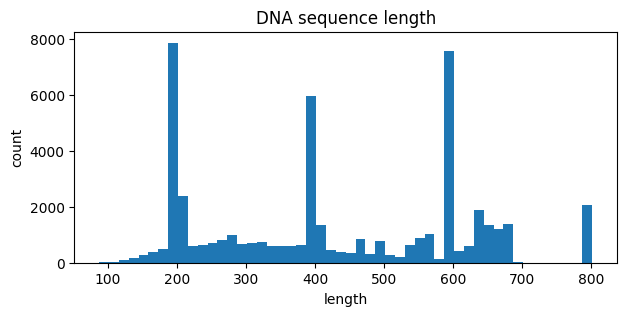

In [5]:
# 클래스 분포 확인
print("클래스 분포:")
print(dataset["label"].value_counts().sort_index())

# 서열 길이 분포 확인
lengths = dataset["seq"].str.len()
print("\n서열 길이 통계:")
print(lengths.describe())

plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=50)
plt.title("DNA sequence length")
plt.xlabel("length")
plt.ylabel("count")
plt.show()

----------
## 2. DNA 서열을 숫자로 바꾸기 — 원-핫 인코딩

컴퓨터(신경망)는 `"ACGT..."` 같은 **문자**를 바로 이해하지 못함.  
숫자로 바꿔줘야 함.

가장 직관적인 방법이 **원-핫(one-hot) 인코딩** 임.  
각 위치의 염기 하나를
**5칸짜리 0/1 벡터**로 표현함 (A,C,G,T,N 순서):

```
A → [1, 0, 0, 0, 0]
C → [0, 1, 0, 0, 0]
G → [0, 0, 1, 0, 0]
T → [0, 0, 0, 1, 0]
N → [0, 0, 0, 0, 1]
```

그러면 서열 하나는 `(서열길이, 5)` 크기의 표(이미지처럼 생긴 2차원 배열)가 됨.  
CNN은 이 "그림"을 왼쪽에서 오른쪽으로 훑으며 패턴을 찾음.

> **길이를 맞춰야 함:** 서열 길이가 제각각이라, 너무 길면 자르고(truncate) 짧으면 0으로 채움(padding)

> 현재는 모두 똑같은 길이 `MAXLEN` 으로 맞춤. (padding 사용)


예시 10글자    : CAGTANGTGA  (가운데 N은 시연용으로 삽입)
원-핫 shape    : (1, 10, 5)   (1개 서열, 길이 10, 5채널)


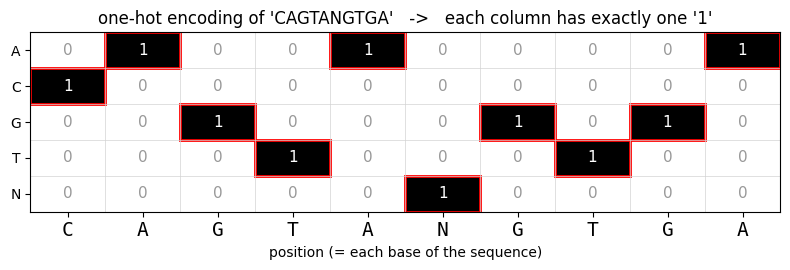

→ 세로축 A/C/G/T/N 중 그 위치의 염기 칸만 1(검정), 나머지는 0(흰색).
  N(가운데) 자리는 맨 아래 N 채널에 1 → A/C/G/T 어디에도 안 켜짐.
  서열 하나 = 이런 (길이 × 5) 표 한 장. CNN은 이 '그림'을 왼쪽에서 오른쪽으로 훑음.


In [20]:
#@title ▶️ [실행만 하세요] 원-핫 인코딩 함수 + 예시 그림  { display-mode: "form" }
# 모든 서열을 맞출 고정 길이. (긴 건 잘리고, 짧은 건 뒤를 0으로 채움)
# 이 데이터는 길이가 87~802이고 가장 긴 게 802 (극단적 outlier 없음).
# → 802로 맞추면 어떤 서열도 안 잘리고(무손실), 패딩만 생긴다.
#   (참고: 500으로 하면 약 40%가 뒤가 잘려서 정보 손실이 큼)
MAXLEN = 802

BASES = "ACGTN"                       # 채널 순서 (A,C,G,T,N → 5채널)
base_to_idx = {b: i for i, b in enumerate(BASES)}

# 아스키 코드 → 채널 번호 변환표 (없는 문자는 -1 = 무시)
lookup = np.full(256, -1, dtype=np.int64)
for b, i in base_to_idx.items():
    lookup[ord(b)] = i


def one_hot_encode(seqs, maxlen=MAXLEN):
    """문자열 서열들을 (개수, maxlen, 5) 크기의 원-핫 배열로 변환."""
    n = len(seqs)
    X = np.zeros((n, maxlen, len(BASES)), dtype=np.float32)
    for i, s in enumerate(seqs):
        s = s[:maxlen]                                   # 너무 길면 자르기
        arr = np.frombuffer(s.encode("ascii"), np.uint8) # 문자 → 아스키 코드
        idx = lookup[arr]                                # → 채널 번호
        pos = np.where(idx >= 0)[0]                       # 유효한 위치만
        X[i, pos, idx[pos]] = 1.0                         # 해당 칸에 1 표시
    return X


# 예시: 첫 서열의 앞 10글자가 원-핫으로 어떻게 바뀌는지 '그림'으로 확인
# (N 채널도 보이도록, 실제 서열 앞부분 가운데에 'N' 1개를 일부러 끼워 넣음.
#  N = 어떤 염기인지 모르는(불확실) 자리 → 5번째 채널에 1로 인코딩됨)
from matplotlib.patches import Rectangle

_real = dataset["seq"].iloc[0]
sample_seq = _real[:5] + "N" + _real[5:9]               # 실제 9글자 + 가운데 N 1개 = 길이 10
example = one_hot_encode([sample_seq], maxlen=10)        # (1, 10, 5)
print("예시 10글자    :", sample_seq, " (가운데 N은 시연용으로 삽입)")
print("원-핫 shape    :", example.shape, "  (1개 서열, 길이 10, 5채널)")

grid = example[0].T                                       # (5채널, 10위치): 행=ACGTN, 열=서열 위치
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.imshow(grid, cmap="Greys", vmin=0, vmax=1, aspect="auto")  # 1=검정, 0=흰색
ax.set_yticks(range(5)); ax.set_yticklabels(list(BASES))
ax.set_xticks(range(len(sample_seq)))
ax.set_xticklabels(list(sample_seq), family="monospace", fontsize=14)
ax.set_xlabel("position (= each base of the sequence)")
ax.set_title(f"one-hot encoding of '{sample_seq}'   ->   each column has exactly one '1'")

# 각 칸에 0/1 숫자 적기 (맨숫자도 그대로 보이게)
for r in range(5):
    for c in range(len(sample_seq)):
        v = int(grid[r, c])
        ax.text(c, r, v, ha="center", va="center",
                color="white" if v else "0.6", fontsize=11)
# '1'인 칸(=그 위치의 염기)을 빨강 테두리로 강조
for c in range(len(sample_seq)):
    r = int(grid[:, c].argmax())
    ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="red", lw=2))

# 칸 구분 격자
ax.set_xticks(np.arange(-0.5, len(sample_seq), 1), minor=True)
ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
ax.grid(which="minor", color="lightgray", lw=0.5)
ax.tick_params(which="minor", length=0)
plt.tight_layout(); plt.show()

print("→ 세로축 A/C/G/T/N 중 그 위치의 염기 칸만 1(검정), 나머지는 0(흰색).")
print("  N(가운데) 자리는 맨 아래 N 채널에 1 → A/C/G/T 어디에도 안 켜짐.")
print("  서열 하나 = 이런 (길이 × 5) 표 한 장. CNN은 이 '그림'을 왼쪽에서 오른쪽으로 훑음.")


In [7]:
# 전체 데이터를 원-핫으로 변환 (수십 초 정도 걸릴 수 있어요)
X = one_hot_encode(dataset["seq"].values)
y = dataset["label"].values

X_problem = one_hot_encode(problemset["seq"].values)

print("학습용 X shape :", X.shape, " (서열 수, 길이, 채널)")
print("문제용 X shape :", X_problem.shape)

학습용 X shape : (50000, 802, 5)  (서열 수, 길이, 채널)
문제용 X shape : (10000, 802, 5)


### 학습용 / 검증용 나누기

모델이 처음 보는 데이터에서도 잘 맞히는지 확인하려고, 학습 데이터를
**train(80%)** 과 **validation(20%)** 으로 나눔.


In [8]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("train:", x_train.shape, "  validation:", x_val.shape)

train: (40000, 802, 5)   validation: (10000, 802, 5)


----------
## 3. 1D CNN 모델 만들기

이제 핵심인 CNN 모델을 만듦.  
각 부품(layer)이 무슨 일을 하는지 아래에 정리함.  
(아래 3가지가 이번 **최소 모델의 전부**임. `MaxPooling1D`·`Dropout` 같은 부품은 **7. 더 해보기**에서 직접 추가하며 실험)

| 레이어 | 하는 일 |
|---|---|
| **Conv1D** | 작은 **돋보기(필터)** 가 서열을 훑으며 특정 패턴(모티프)을 찾음. 필터 개수만큼 다른 패턴을 동시에 탐색 (= **모티프 검출기**) |
| **GlobalMaxPooling1D** | 서열 전체에서 "각 패턴(필터)이 **가장 강하게 매칭된 정도**" 하나씩만 뽑아 요약 |
| **Fully Connected Layer (FC)** `Dense(3, softmax)` | 0/1/2 **세 클래스의 확률**을 출력 |

`kernel_size` 는 돋보기의 폭(한 번에 몇 글자를 보는지), `filters` 는 돋보기 개수임.

> `One-hot → Conv1D(필터 슬라이딩) → Feature Maps → GlobalMaxPool → FC+Softmax(3-class 확률)`

> 학습이 끝나면 **필터 가중치 자체가 "모델이 찾은 모티프"** 가 되어, 시각화하면 TATA·CAAT 같은 실제 모티프와 닮은 모양이 보이기도 함.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

# === 최소 구조 (Conv1D 1개) ===
# 개념 그대로: 패턴 찾기(Conv1D) → 가장 강한 봉우리 뽑기(GlobalMaxPool) → 분류(Fully Connected Layer)
# 층을 더 쌓고 싶으면 '7. 더 해보기'에서 직접 추가하며 점수를 비교해 보세요.
model = models.Sequential([
    layers.Input(shape=(MAXLEN, len(BASES))),          # 입력: (길이 802, 채널 5)

    layers.Conv1D(64, kernel_size=6, padding="same", activation="relu"),  # 모티프 검출기 64개 (same=양끝 0패딩 → 길이 802 유지)
    layers.GlobalMaxPooling1D(),                       # 서열 전체를 64개 숫자로 요약 (가장 강한 매치)

    layers.Dense(3, activation="softmax", name="fully_connected"),  # 완전연결층(FC): 64개 점수 → 3클래스 확률
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # 라벨이 정수(0/1/2)일 때 사용
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 802, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fully_connected (Dense)         │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,179 (8.51 KB)

 Trainable params: 2,179 (8.51 KB)

 Non-trainable params: 0 (0.00 B)

### 구조 보는 법 — 데이터가 어떻게 흘러가나

그림은 **바로 위에서 만든(제출용) 모델 구조 그대로**임.  
왼쪽에서 오른쪽으로 따라가면 됨.

1. **one-hot input `(802, 5)`** — DNA 서열(예: `GCTATAA…`)을 길이를 맞춘 뒤, 염기(A/C/G/T/N)를 0·1 벡터로 바꾼 표.
2. **Feature Maps `(802, 64)`** — 주황 6×5 커널(돋보기, Conv1D)이 `TATAAA` 같은 짧은 패턴(모티프)을 찾음.
서열을 한 칸씩 **슬라이딩하며 곱하고 더해(dot-product)** 점수를 매김.
이런 커널이 **64개** 있고, 각자 다른 패턴을 학습함.
👉 길이가 **802 그대로**인 이유는 `padding="same"` — 6칸 커널을 그냥 훑으면 끝이 모자라 797로 줄지만, 양끝에 0을 채워(패딩) 끝 글자까지 보게 해 입력과 같은 **802로 맞춤**. (뒤에 나오는 슬라이딩 애니메이션의 회색 `0` 칸이 바로 이 패딩)
3. **GlobalMaxPool `(64,)`** — 필터마다 **서열 전체에서 가장 강하게 반응한 한 값**만 뽑음.
"이 패턴이 어디에 있든 한 번이라도 강하게 나왔나?" → 위치에 무관(position-invariant)한 요약.
4. **Fully Connected Layer (FC) + softmax** — 64개 요약 점수를 바로 종합해 **enhancer(0) / promoter(1) / OCR(2)** 세 클래스의 확률을 출력함.

> 핵심: Conv1D는 "패턴(모티프) 검출기", GlobalMaxPool은 "그 패턴이 서열 어딘가에 있었는지"를 모으는 단계, Fully Connected Layer(FC)는 그 단서들을 모아 "무슨 영역인지" 판정하는 단계임.

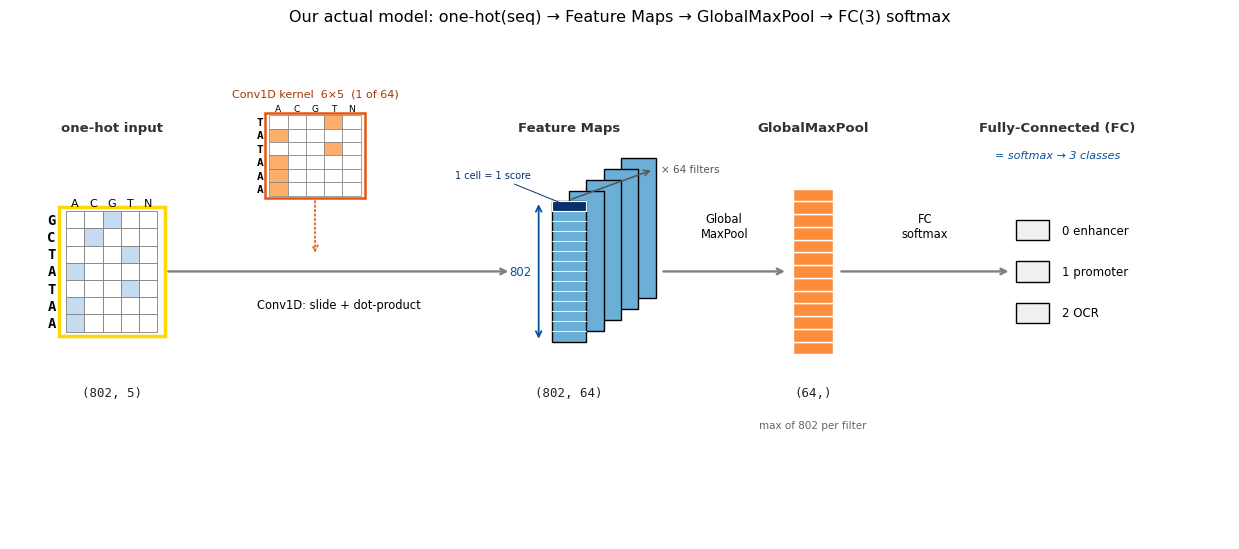

Feature Maps 블록(= Conv1D 출력): 파란 띠 1장 = 필터 1개 = 길이 802짜리 배열. 그게 64장 쌓인 게 (802, 64).
칸(파란 셀) 1개 = 슬라이드 1번의 점수 1개. GlobalMaxPool이 띠마다 802칸 중 최댓값 1개씩만 뽑아 → 64개.
주황 6×5 = Conv1D 커널 1개(돋보기, TATAAA)가 서열을 훑음(×64개) → FC(완전연결층, Dense)이 3클래스 판정.


In [10]:
#@title ▶️ [실행만 하세요] 모델 구조 그림  { display-mode: "form" }
# 【모델 구조 그림 — 실제 제출 모델 그대로】 최소 구조: Feature Maps(Conv1D 출력) → GlobalMaxPool → FC(완전연결)
# one-hot(염기서열) → Conv1D 커널이 슬라이딩 → Feature Maps(×64) → GlobalMaxPool → softmax(3클래스)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12.5, 5.6))
ax.set_xlim(0, 12); ax.set_ylim(0, 8); ax.axis("off")
yc = 4.2
BASES = "ACGTN"; b2i = {b: i for i, b in enumerate(BASES)}
SEG = 14

# 필터-스택: 필터 1개 = 길이 802짜리 1D 배열(세로 띠). n_show장 쌓아 '×64'를 상징.
def filter_stack(xc, n_show, color, strip_w=0.34, strip_h=2.2, seg=SEG, off=0.17):
    for s in range(n_show - 1, -1, -1):
        x0 = xc - strip_w / 2 + s * off
        y0 = yc - strip_h / 2 + s * off
        ax.add_patch(Rectangle((x0, y0), strip_w, strip_h,
                               facecolor=color, edgecolor="black", lw=1.0))
        if s == 0:                                   # 앞면 띠만 '길이 방향(세로)'으로 칸 나눔 = 1D 배열
            for r in range(1, seg):
                ax.plot([x0, x0 + strip_w], [y0 + r * strip_h / seg] * 2,
                        color="white", lw=0.6)
            ax.add_patch(Rectangle((x0, y0 + (seg - 1) * strip_h / seg), strip_w,
                                   strip_h / seg, facecolor="#08306b", edgecolor="white", lw=0.8))
    left = xc - strip_w / 2
    right = xc + strip_w / 2 + (n_show - 1) * off
    return left, right, xc - strip_w / 2, strip_w, strip_h

def vector_col(xc, ncells, ch, color):
    h = ncells * ch
    for r in range(ncells):
        ax.add_patch(Rectangle((xc - 0.2, yc - h / 2 + r * ch), 0.4, ch,
                               facecolor=color, edgecolor="white", lw=1))
    return xc - 0.2, xc + 0.2

def op(xa, xb, text, dy=0.5):
    ax.annotate("", xy=(xb, yc), xytext=(xa, yc),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.7))
    ax.text((xa + xb) / 2, yc + dy, text, ha="center", va="bottom", fontsize=8.3)

def shp(xc, s): ax.text(xc, yc - 1.95, s, ha="center", fontsize=9, family="monospace", color="#222")
def name(xc, s): ax.text(xc, yc + 2.2, s, ha="center", fontsize=9.5, fontweight="bold", color="#333")

# ── (1) one-hot 입력: 실제 염기서열 글자까지 표시 ──
demo = "GCTATAA"
cw, chh, gx = 0.18, 0.27, 0.55
gtop = yc + len(demo) * chh / 2
for r, base in enumerate(demo):
    for c in range(5):
        fc = "#c6dbef" if c == b2i[base] else "white"
        ax.add_patch(Rectangle((gx + c * cw, gtop - (r + 1) * chh), cw, chh,
                               facecolor=fc, edgecolor="gray", lw=0.6))
    ax.text(gx - 0.1, gtop - (r + 0.5) * chh, base, ha="right", va="center",
            fontsize=10, family="monospace", fontweight="bold")
for c, b in enumerate(BASES):
    ax.text(gx + (c + 0.5) * cw, gtop + 0.05, b, ha="center", va="bottom", fontsize=8)
ax.add_patch(Rectangle((gx - 0.07, gtop - len(demo) * chh - 0.07), 5 * cw + 0.14,
                       len(demo) * chh + 0.14, fill=False, edgecolor="gold", lw=2.5))
in_cx, in_r = gx + 2.5 * cw, gx + 5 * cw
name(in_cx, "one-hot input"); shp(in_cx, "(802, 5)")

# ── Conv1D 커널(돋보기) 인셋 — 염기서열(ACGTN 헤더 + 패턴 글자)까지 ──
kpat = "TATAAA"; kcx, kcw, kch = 3.0, 0.18, 0.21
kx = kcx - 2.5 * kcw; ktop = yc + 2.45
for r, base in enumerate(kpat):
    for c in range(5):
        fc = "#fdae6b" if c == b2i[base] else "white"
        ax.add_patch(Rectangle((kx + c * kcw, ktop - (r + 1) * kch), kcw, kch,
                               facecolor=fc, edgecolor="gray", lw=0.5))
    ax.text(kx - 0.06, ktop - (r + 0.5) * kch, base, ha="right", va="center",
            fontsize=8, family="monospace", fontweight="bold")
for c, b in enumerate(BASES):
    ax.text(kx + (c + 0.5) * kcw, ktop + 0.03, b, ha="center", va="bottom", fontsize=6.5)
ax.add_patch(Rectangle((kx - 0.04, ktop - 6 * kch - 0.04), 5 * kcw + 0.08, 6 * kch + 0.08,
                       fill=False, edgecolor="#e6550d", lw=1.8))
ax.text(kcx, ktop + 0.30, "Conv1D kernel  6×5  (1 of 64)", ha="center", fontsize=8, color="#a63603")
ax.annotate("", xy=(kcx, yc + 0.25), xytext=(kcx, ktop - 6 * kch - 0.04),
            arrowprops=dict(arrowstyle="->", color="#e6550d", lw=1.2, linestyle="dotted"))

# ── (2) Feature Maps (Conv1D 출력) : 필터 1개 = 802짜리 1D 배열(세로 띠), 그게 64장 ──
c1 = 5.5
l, r1, fx0, sw, sh = filter_stack(c1, 5, "#6baed6")
name(c1, "Feature Maps"); shp(c1, "(802, 64)")
# 길이(802) — 세로 양화살표 + 가로 라벨
ax.annotate("", xy=(fx0 - 0.13, yc + sh / 2), xytext=(fx0 - 0.13, yc - sh / 2),
            arrowprops=dict(arrowstyle="<->", color="#08519c", lw=1.3))
ax.text(fx0 - 0.20, yc, "802", ha="right", va="center", fontsize=8.5, color="#08519c")
# 깊이(×64) — 스택 위쪽 화살표
ax.annotate("", xy=(r1 - 0.02, yc + sh / 2 + 0.5), xytext=(fx0 + sw / 2, yc + sh / 2 + 0.02),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.1))
ax.text(r1 + 0.05, yc + sh / 2 + 0.5, "× 64 filters", ha="left", va="center",
        fontsize=7.5, color="#555")
# 한 칸 = 점수 1개 (위쪽, 강조 셀에서 리더선)
ax.annotate("1 cell = 1 score", xy=(fx0 + sw / 2, yc + sh / 2 - sh / (2 * SEG)),
            xytext=(c1 - 0.75, yc + sh / 2 + 0.33), ha="center", va="bottom", fontsize=7,
            color="#08306b", arrowprops=dict(arrowstyle="-", color="#08306b", lw=0.7))

# ── (3) GlobalMaxPooling → 벡터 (64유닛을 13칸으로 축약 표현) ──
g = 7.9; lg, rg = vector_col(g, 13, 0.20, "#fd8d3c")
name(g, "GlobalMaxPool"); shp(g, "(64,)")
ax.text(g, yc - 2.45, "max of 802 per filter", ha="center", fontsize=7.5, color="#666")

# ── (4) Fully Connected (FC) + softmax → 클래스 ──
o = 9.9
for i, lab in enumerate(["0 enhancer", "1 promoter", "2 OCR"]):
    ax.add_patch(Rectangle((o, yc + 0.49 - i * 0.65), 0.32, 0.32, facecolor="#f0f0f0", edgecolor="black"))
    ax.text(o + 0.45, yc + 0.65 - i * 0.65, lab, ha="left", va="center", fontsize=8.5)
name(o + 0.4, "Fully-Connected (FC)")
ax.text(o + 0.4, yc + 1.78, "= softmax → 3 classes", ha="center", fontsize=8, fontstyle="italic", color="#08519c")

# ── 화살표 + 연산 이름 ──
ax.annotate("", xy=(l - 0.4, yc), xytext=(in_r + 0.08, yc),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.7))
ax.text((in_r + 0.08 + l - 0.4) / 2, yc - 0.42, "Conv1D: slide + dot-product",
        ha="center", va="top", fontsize=8.3)
op(r1 + 0.05, lg - 0.05, "Global\nMaxPool")
op(rg + 0.05, o - 0.05, "FC\nsoftmax")

ax.set_title("Our actual model: one-hot(seq) → Feature Maps → GlobalMaxPool → FC(3) softmax",
             fontsize=11.5)
plt.tight_layout(); plt.show()

print("Feature Maps 블록(= Conv1D 출력): 파란 띠 1장 = 필터 1개 = 길이 802짜리 배열. 그게 64장 쌓인 게 (802, 64).")
print("칸(파란 셀) 1개 = 슬라이드 1번의 점수 1개. GlobalMaxPool이 띠마다 802칸 중 최댓값 1개씩만 뽑아 → 64개.")
print("주황 6×5 = Conv1D 커널 1개(돋보기, TATAAA)가 서열을 훑음(×64개) → FC(완전연결층, Dense)이 3클래스 판정.")


### Fully Connected Layer (FC) + softmax 자세히 — 64개 점수가 어떻게 3개 확률이 되나

위 구조 그림의 **마지막 단계(Fully Connected Layer + softmax)** 만 확대한 것임.

1. **입력**: GlobalMaxPool이 만든 **64개 점수**(필터별 "이 모티프가 서열 어딘가 있었나").
2. **Fully Connected Layer (FC, 뉴런 3개)**: 입력 64개와 모두 연결된 **신경망 한 층**. 뉴런마다 64개 점수를 *각자 다른 가중치로 곱해 더해* 클래스 점수(원점수, logit)를 1개씩 만듦 → 3개. (학습되는 값 = 가중치 64×3 + 편향 3 = **195개**, 위 `model.summary()` 의 `fully_connected` 층 파라미터 수와 일치)
3. **softmax**: 원점수 3개를 **합이 1인 확률**로 바꿈 — 각각 exp(지수) 씌워 전체 합으로 나눔. 큰 값은 더 키우고 작은 값은 눌러 "가장 그럴듯한 클래스"가 도드라짐.
4. **argmax**: 그중 **가장 큰 확률**의 클래스를 최종 예측으로 선택.

> 코드에선 `Dense(3, activation="softmax")`(= Fully Connected Layer) **한 줄**에 2·3단계가 같이 들어 있음. 즉 "신경망이 점수 3개를 내고 → softmax로 확률로 바꾼다".

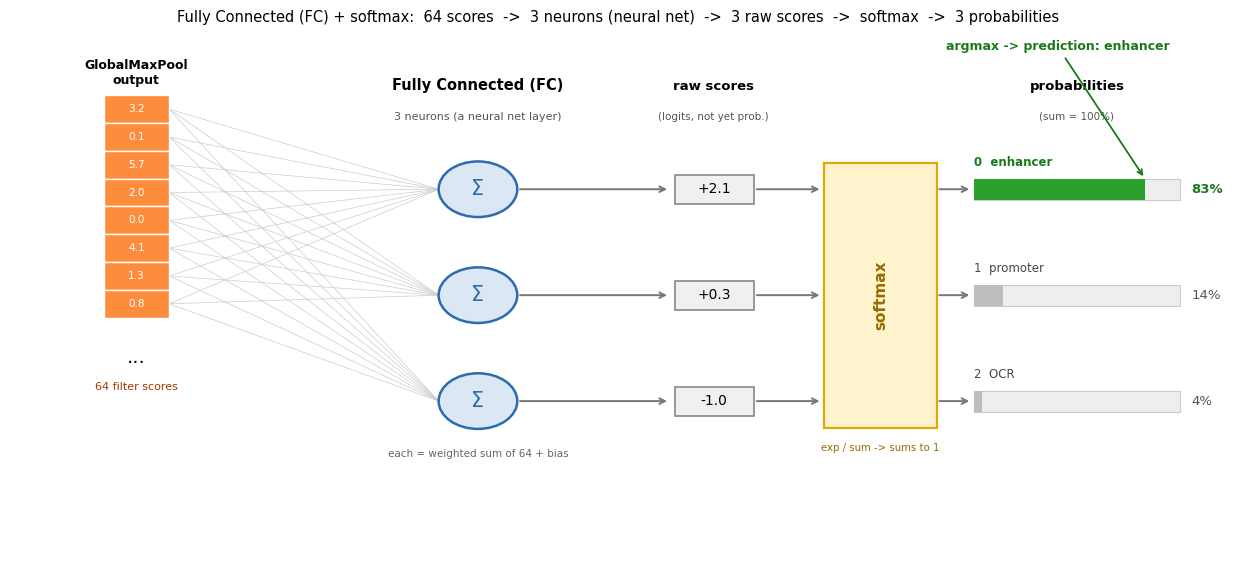

Fully Connected Layer(FC): 64개 점수를 클래스마다 다른 가중치로 합산 → 원점수(logit) 3개. (파라미터 64×3+3=195개)
softmax: 원점수 3개를 exp 씌워 전체 합으로 나눔 → 합이 1인 확률 3개.
argmax : 가장 큰 확률의 클래스를 최종 예측으로 선택 (이 예시엔 0=enhancer).


In [11]:
#@title ▶️ [실행만 하세요] Fully Connected Layer (FC) + softmax 가 64개를 3확률로 바꾸는 과정  { display-mode: "form" }
# 【Fully Connected Layer (FC) + softmax 자세히】 GlobalMaxPool의 64개 점수 → 신경망 3뉴런 → 원점수 3개 → softmax → 확률 3개
# (예시 숫자로 흐름만 보여주는 그림. 학습·제출과 무관 / 글자는 폰트 깨짐 방지로 영어)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

fig, ax = plt.subplots(figsize=(12.5, 5.8))
ax.set_xlim(0, 13); ax.set_ylim(0, 8); ax.axis("off")

# ---------- (1) INPUT: 64 filter scores (GlobalMaxPool output) ----------
ix = 1.0; cell_h = 0.42; n_show = 8
in_vals = [3.2, 0.1, 5.7, 2.0, 0.0, 4.1, 1.3, 0.8]
in_ys = []; top = 6.6
for i in range(n_show):
    y = top - i * cell_h
    in_ys.append(y + cell_h / 2)
    ax.add_patch(Rectangle((ix, y), 0.7, cell_h, facecolor="#fd8d3c", edgecolor="white", lw=1))
    ax.text(ix + 0.35, y + cell_h / 2, f"{in_vals[i]:.1f}", ha="center", va="center", fontsize=7.5, color="white")
ax.text(ix + 0.35, top - n_show * cell_h - 0.18, "...", ha="center", va="center", fontsize=14)
ax.text(ix + 0.35, top + 0.55, "GlobalMaxPool\noutput", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.text(ix + 0.35, top - n_show * cell_h - 0.55, "64 filter scores", ha="center", va="top", fontsize=8, color="#a63603")

# ---------- (2) FULLY CONNECTED LAYER (FC): 3 neurons ----------
nx = 5.0; ny = [5.6, 4.0, 2.4]
classes = ["0  enhancer", "1  promoter", "2  OCR"]
for y0 in in_ys:
    for yn in ny:
        ax.plot([ix + 0.7, nx - 0.42], [y0, yn], color="#cccccc", lw=0.5, zorder=0)
for k, yn in enumerate(ny):
    ax.add_patch(Circle((nx, yn), 0.42, facecolor="#dbe7f3", edgecolor="#2b6cb0", lw=1.8, zorder=3))
    ax.text(nx, yn, "Σ", ha="center", va="center", fontsize=15, color="#2b6cb0", zorder=4)
ax.text(nx, 7.1, "Fully Connected (FC)", ha="center", fontsize=10.5, fontweight="bold")
ax.text(nx, 6.65, "3 neurons (a neural net layer)", ha="center", fontsize=8, color="#555")
ax.text(nx, 1.55, "each = weighted sum of 64 + bias", ha="center", fontsize=7.5, color="#666")

# ---------- (3) LOGITS: 3 raw scores ----------
lx = 7.1; logits = [2.1, 0.3, -1.0]
for k, yn in enumerate(ny):
    ax.annotate("", xy=(lx - 0.05, yn), xytext=(nx + 0.42, yn), arrowprops=dict(arrowstyle="->", color="#777", lw=1.4))
    ax.add_patch(Rectangle((lx, yn - 0.22), 0.85, 0.44, facecolor="#f0f0f0", edgecolor="#888", lw=1.2))
    ax.text(lx + 0.425, yn, f"{logits[k]:+.1f}", ha="center", va="center", fontsize=10)
ax.text(lx + 0.42, 7.1, "raw scores", ha="center", fontsize=9.5, fontweight="bold")
ax.text(lx + 0.42, 6.65, "(logits, not yet prob.)", ha="center", fontsize=7.5, color="#555")

# ---------- (4) SOFTMAX ----------
sx = 8.7
ax.add_patch(Rectangle((sx, 2.0), 1.2, 4.0, facecolor="#fff3cd", edgecolor="#e0a800", lw=1.6))
ax.text(sx + 0.6, 4.0, "softmax", ha="center", va="center", fontsize=11, fontweight="bold", color="#946c00", rotation=90)
for k, yn in enumerate(ny):
    ax.annotate("", xy=(sx - 0.02, yn), xytext=(lx + 0.85, yn), arrowprops=dict(arrowstyle="->", color="#777", lw=1.4))
ax.text(sx + 0.6, 1.65, "exp / sum -> sums to 1", ha="center", fontsize=7.3, color="#946c00")

# ---------- (5) PROBABILITIES: 3 bars ----------
px = 10.3; probs = [0.83, 0.14, 0.04]; barmax = 2.2
colors = ["#2ca02c", "#bdbdbd", "#bdbdbd"]
for k, yn in enumerate(ny):
    ax.annotate("", xy=(px - 0.02, yn), xytext=(sx + 1.2, yn), arrowprops=dict(arrowstyle="->", color="#777", lw=1.4))
    ax.add_patch(Rectangle((px, yn - 0.16), barmax, 0.32, facecolor="#eeeeee", edgecolor="#cccccc", lw=0.8))
    ax.add_patch(Rectangle((px, yn - 0.16), barmax * probs[k], 0.32, facecolor=colors[k], edgecolor="none"))
    ax.text(px + barmax + 0.12, yn, f"{probs[k]*100:.0f}%", ha="left", va="center",
            fontsize=9.5, fontweight=("bold" if k == 0 else "normal"), color=("#1a7a1a" if k == 0 else "#555"))
    ax.text(px, yn + 0.30, classes[k], ha="left", va="bottom", fontsize=8.5,
            fontweight=("bold" if k == 0 else "normal"), color=("#1a7a1a" if k == 0 else "#444"))
ax.text(px + barmax / 2, 7.1, "probabilities", ha="center", fontsize=9.5, fontweight="bold")
ax.text(px + barmax / 2, 6.65, "(sum = 100%)", ha="center", fontsize=7.5, color="#555")

# ---------- argmax winner ----------
ax.annotate("argmax -> prediction: enhancer", xy=(px + barmax * 0.83, ny[0] + 0.16),
            xytext=(px - 0.3, 7.7), ha="left", fontsize=9, color="#1a7a1a", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#1a7a1a", lw=1.3))

ax.set_title("Fully Connected (FC) + softmax:  64 scores  ->  3 neurons (neural net)  ->  3 raw scores  ->  softmax  ->  3 probabilities", fontsize=10.5)
plt.tight_layout(); plt.show()

print("Fully Connected Layer(FC): 64개 점수를 클래스마다 다른 가중치로 합산 → 원점수(logit) 3개. (파라미터 64×3+3=195개)")
print("softmax: 원점수 3개를 exp 씌워 전체 합으로 나눔 → 합이 1인 확률 3개.")
print("argmax : 가장 큰 확률의 클래스를 최종 예측으로 선택 (이 예시엔 0=enhancer).")


### (이해용) Conv1D는 안에서 무슨 계산을 하는가

> 위에서 모델 **구조**를 먼저 봤음. 그중 핵심인 `Conv1D` 한 줄이 **내부에서 실제로 무슨 계산을 하는지** 학습 전에 펼쳐 봄.

`layers.Conv1D(64, kernel_size=6, ...)` 한 줄 안에는 **커널(6×5 표)이 서열을 한 칸씩 훑으며 점수를 매기는** 과정이 들어 있음.  
코드에 `for`문이 안 보이는 건 TensorFlow가 대신 처리하기 때문임.

아래 **애니메이션**이 그 과정을 직접 펼쳐서 보여줌.  
(학습·제출과 무관)

- **① 데이터**: DNA 서열 한 줄 → 원-핫 (그림)
- **② 커널(돋보기)**: `TATAAA`(TATA box)에 반응하도록 만든 `6×5` 표 1개
- **③ 슬라이딩 + 계산**: 돋보기가 한 칸씩 미끄러질 때마다, 겹친 6글자에 대해 **곱하고 더하는(내적)** 식과 그 점수를 같이 보여줌

> 점수가 어디서 나왔는지(예: `T·2 + A·2 + … = 12`)를 **매 칸마다 식으로 확인**할 수 있음.  
> Conv1D는 마법이 아니라 곱셈+덧셈일 뿐.  
> 실제 모델에서는 ②의 숫자를 직접 적지 않음.  
> 학습(`model.fit`)이 값을 채움.

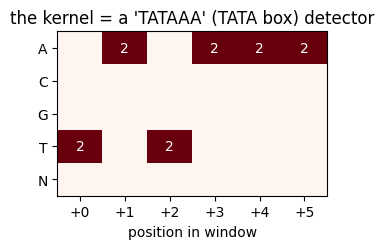

In [12]:
#@title ▶️ [실행만 하세요] Conv1D 슬라이딩 애니메이션 (개념 이해용)  { display-mode: "form" }
# 【애니메이션 데모】 1D 컨볼루션: 돋보기가 한 칸씩 미끄러지며 '곱하고 더해' 점수를 매기는 과정
# 모델과 동일하게 padding="same": 서열 양끝에 0을 채워(회색 '0' 칸) 끝까지 훑음 → 출력 길이 = 입력 길이.
# Colab/Jupyter 에서 ▶ 재생 버튼이 달린 애니메이션으로 보임. (글자는 폰트 깨짐 방지로 영어)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

BASES_DEMO = "ACGTN"
seq_str = "GCTATAAAGGCTTATAAACGTAC"   # 길게: 'TATAAA'(TATA box) 모티프가 2번 등장
K = 6                                  # 윈도우 폭 = kernel_size

def to_onehot(s):
    idx = {b: i for i, b in enumerate(BASES_DEMO)}
    oh = np.zeros((len(s), 5), dtype=int)
    for r, ch in enumerate(s):
        oh[r, idx[ch]] = 1
    return oh

seq = to_onehot(seq_str)               # (L, 5)
L = len(seq_str)
#                  A  C  G  T  N        'TATAAA'(TATA box)에 반응하는 6x5 돋보기
kernel = np.array([
    [0, 0, 0, 2, 0],   # T
    [2, 0, 0, 0, 0],   # A
    [0, 0, 0, 2, 0],   # T
    [2, 0, 0, 0, 0],   # A
    [2, 0, 0, 0, 0],   # A
    [2, 0, 0, 0, 0],   # A
])

# === 모델과 동일하게 padding="same": 양끝에 0을 채워 출력 길이 = 입력 길이 ===
PAD_L, PAD_R = 2, 3                                   # Keras 'same' (K=6, stride 1): 왼쪽 2 + 오른쪽 3
seq_pad = np.vstack([np.zeros((PAD_L, 5), dtype=int), seq, np.zeros((PAD_R, 5), dtype=int)])
Lp = L + PAD_L + PAD_R                                # 패딩 포함 길이
seq_str_pad = "0" * PAD_L + seq_str + "0" * PAD_R     # 글자 표시용 ('0' = 제로패딩)
n_pos = L                                            # same → 출력 길이 = 입력 길이(=L)
scores = np.array([int(np.sum(seq_pad[s:s + K] * kernel)) for s in range(n_pos)])

# ── (그림 1) 커널(돋보기) 자체를 이미지로 ──────────────────────────────
fig_k, axk = plt.subplots(figsize=(3.2, 2.6))
axk.imshow(kernel.T, cmap="Reds", aspect="auto")
axk.set_yticks(range(5)); axk.set_yticklabels(list(BASES_DEMO))
axk.set_xticks(range(K)); axk.set_xticklabels([f"+{i}" for i in range(K)])
axk.set_xlabel("position in window"); axk.set_title("the kernel = a 'TATAAA' (TATA box) detector")
for r in range(K):
    for c in range(5):
        if kernel[r, c]:
            axk.text(r, c, kernel[r, c], ha="center", va="center", color="white")
plt.tight_layout(); plt.show()

# ── (그림 2) 애니메이션: 글자 / 원-핫 / [계산식] / 점수 4단으로 슬라이딩 ──────
# 양끝 회색 '0' = 제로패딩(same). 커널이 패딩 위까지 훑어 출력 길이가 입력과 같아짐.
fig, (axL, axOH, axCalc, axS) = plt.subplots(
    4, 1, figsize=(11, 7.5), gridspec_kw={"height_ratios": [1, 2.2, 0.6, 2.4]})
fig.subplots_adjust(top=0.93, bottom=0.08, left=0.09, right=0.97, hspace=0.35)

# 윗단: 서열 글자 박스 (고정 배경). 패딩 칸은 회색 '0'
for i, ch in enumerate(seq_str_pad):
    is_pad = (i < PAD_L) or (i >= PAD_L + L)
    axL.add_patch(Rectangle((i, 0), 1, 1, fill=is_pad,
                            facecolor="#e6e6e6", edgecolor="lightgray"))
    axL.text(i + 0.5, 0.5, ch, ha="center", va="center", fontsize=13,
             family="monospace", color=("#999" if is_pad else "black"))
axL.set_xlim(0, Lp); axL.set_ylim(0, 1); axL.set_xticks([]); axL.set_yticks([])
axL.set_title("DNA sequence  (gray 0 = zero-padding for 'same')")

# 가운뎃단: 원-핫 인코딩 이미지 (고정 배경). 패딩 영역은 파란 음영
axOH.imshow(seq_pad.T, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axOH.set_yticks(range(5)); axOH.set_yticklabels(list(BASES_DEMO))
axOH.set_xticks(range(Lp)); axOH.set_xticklabels(list(seq_str_pad), family="monospace", fontsize=8)
axOH.set_title("one-hot encoding  (blue bands = zero-padding,  rows = A/C/G/T/N)")
axOH.axvspan(-0.5, PAD_L - 0.5, color="#1f77b4", alpha=0.13)
axOH.axvspan(PAD_L + L - 0.5, Lp - 0.5, color="#1f77b4", alpha=0.13)

# 사잇단: 계산식 표시 전용 빈 칸
axCalc.axis("off")

# 아랫단: 점수 곡선이 슬라이딩하며 채워짐 (출력 길이 = 입력 길이)
axS.set_xlim(-0.5, n_pos - 0.5); axS.set_ylim(0, scores.max() + 2)
axS.set_xticks(range(n_pos))
axS.set_xlabel("output position  (same padding → output length = input length)")
axS.set_ylabel("score")
axS.set_title("Conv1D output = matching score at each position\n"
              "(output length = input length, thanks to 'same' padding)")

# 움직이는 요소들 (돋보기 사각형 2개 + 점수 곡선 + 최고점 + 내적 식 라벨)
winL = Rectangle((0, 0), K, 1, fill=True, color="gold", alpha=0.45, ec="red", lw=2.5)
axL.add_patch(winL)
winOH = Rectangle((-0.5, -0.5), K, 5, fill=False, ec="red", lw=2.5)
axOH.add_patch(winOH)
(line,) = axS.plot([], [], "o-", color="steelblue", lw=2)
peak = axS.scatter([], [], s=160, facecolors="none", edgecolors="red", lw=2)
# 내적 식(곱하고 더하기) — one-hot 과 score 사이 빈 칸 한가운데에
calc = axCalc.text(0.5, 0.5, "", ha="center", va="center", fontsize=12.5,
                   family="monospace", transform=axCalc.transAxes,
                   bbox=dict(boxstyle="round", fc="wheat", ec="orange"))

def init():
    line.set_data([], [])
    peak.set_offsets(np.empty((0, 2)))
    calc.set_text("")
    return winL, winOH, line, peak, calc

def update(p):
    winL.set_xy((p, 0))                       # 글자 위 돋보기 이동(패딩 포함 좌표)
    winOH.set_xy((p - 0.5, -0.5))             # 원-핫 위 돋보기 이동
    line.set_data(range(p + 1), scores[:p + 1])
    best = int(np.argmax(scores[:p + 1]))     # 지금까지 최고 점수 위치 강조
    peak.set_offsets([[best, scores[best]]])
    # 현재 윈도우의 내적을 '글자·가중치 + ... = 점수' 식으로 풀어 보여주기 ('0' = 패딩, 항상 0 기여)
    win_letters = seq_str_pad[p:p + K]
    contribs = [int(np.sum(seq_pad[p + j] * kernel[j])) for j in range(K)]
    expr = "  +  ".join(f"{win_letters[j]}·{contribs[j]}" for j in range(K))
    calc.set_text(f"window '{win_letters}'    {expr}  =  {scores[p]}")
    return winL, winOH, line, peak, calc

anim = animation.FuncAnimation(fig, update, frames=n_pos, init_func=init,
                               interval=800, blit=False, repeat=True)   # 한 칸당 0.8초 (천천히)
plt.close(fig)        # 마지막 정지 프레임이 따로 출력되는 것 방지
HTML(anim.to_jshtml())   # ← ▶ 재생/일시정지/슬라이더가 달린 플레이어로 표시


### 그래서 이 출력(점수 곡선)이 어떻게 "분류"로 이어지나

위 애니메이션 맨 아래의 **점수 곡선**이 바로 **Conv1D 한 필터의 출력**임.  
봉우리가 솟은 곳 = 그 모티프(`TATAAA`)가 발견된 위치.

- 실제 모델의 `Conv1D(64, ...)` 는 이런 곡선을 **필터마다 1개씩, 총 64개** 만듦 (필터마다 다른 모티프 담당: TATA용, GC-box용, …).
- 그다음 **`GlobalMaxPooling1D`** 가 각 곡선에서 **가장 높은 봉우리(max) 하나**만 뽑음:
  - max가 크다 → "이 서열 어딘가에 그 모티프가 **있다**" (TATA가 앞에 있든 뒤에 있든 똑같이 잡힘 = **위치 불변성**)
  - max가 작다 → "그 모티프 **없음**"
- 이렇게 모은 **"모티프 발견 점수 64개"** 를 **Fully Connected Layer(FC)** 가 종합해서 → **enhancer(0) / promoter(1) / OCR(2)** 확률을 출력.

> **한 줄 요약:** 위치별 매칭 점수(Conv1D 출력) → 최고 봉우리만 추출(GlobalMaxPool) → 발견된 모티프 조합으로 분류(Fully Connected Layer + softmax).

→ 이 과정을 하는 모델은 **앞(3장)에서 이미 만들고 구조도 살펴봤음**. 이제 **4장**에서 실제로 학습시켜 봄.


----------
## 4. 학습시키기

`epochs` = 전체 데이터를 몇 번 반복 학습할지, `batch_size` = 한 번에 몇 개씩 보고 배울지.

아래를 실행하면 epoch 마다 train/validation 정확도가 올라가는 모습을 볼 수 있음.


In [13]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4967 - loss: 0.9989 - val_accuracy: 0.5349 - val_loss: 0.9086
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5452 - loss: 0.8801 - val_accuracy: 0.5453 - val_loss: 0.8705
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5550 - loss: 0.8570 - val_accuracy: 0.5521 - val_loss: 0.8587
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5627 - loss: 0.8438 - val_accuracy: 0.5580 - val_loss: 0.8493
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5701 - loss: 0.8336 - val_accuracy: 0.5624 - val_loss: 0.8428
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5759 - loss: 0.8257 - val_accuracy: 0.5621 - val_loss: 0.8389
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5804 - loss: 0.8200 - val_accuracy: 0.5659 - val_loss: 0.8366
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5827 - loss: 0.8156 - val_accu

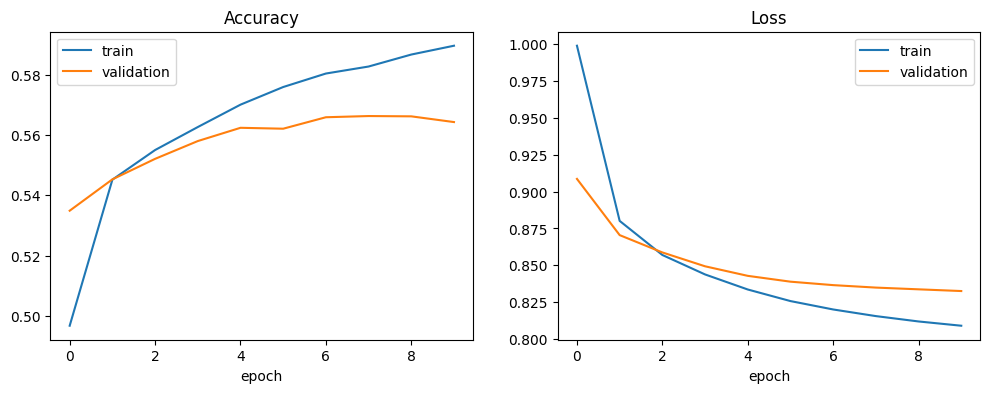

In [14]:
# 학습 곡선 그리기 (정확도 / 손실)
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["accuracy"], label="train")
axes[0].plot(hist["val_accuracy"], label="validation")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(hist["loss"], label="train")
axes[1].plot(hist["val_loss"], label="validation")
axes[1].set_title("Loss"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.show()

### 검증 데이터로 성능 확인

학습에 쓰지 않은 검증 데이터로 성능을 확인함.

> **채점 기준 (강의자료 기준):** 리더보드는 **Accuracy** 로 채점함.  
> 다만 클래스가 3개라, 특정 클래스에서만 무너지는지 보기 위해 **macro F1**(클래스별 F1의 평균)도 함께 확인하는 것을 권장함.  
> (발표자료용 분석 지표)


In [15]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

val_prob = model.predict(x_val)          # 각 클래스 확률
val_pred = val_prob.argmax(axis=1)        # 가장 확률 높은 클래스 선택

print("Validation Accuracy :", accuracy_score(y_val, val_pred))
print("Validation Macro F1 :", f1_score(y_val, val_pred, average="macro"))
print()
print(classification_report(y_val, val_pred, digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Validation Accuracy : 0.5643
Validation Macro F1 : 0.55913553800621

              precision    recall  f1-score   support

           0     0.7449    0.7215    0.7330      3282
           1     0.4740    0.5869    0.5244      3696
           2     0.4927    0.3660    0.4200      3022

    accuracy                         0.5643     10000
   macro avg     0.5705    0.5581    0.5591     10000
weighted avg     0.5685    0.5643    0.5613     10000



----------
## 5. 문제 데이터 예측 & 리더보드 제출

- 제출이 느리다고 중지 후 여러 번 재실행하면 패널티가 발생할 수 있음.
(하루 최대 100회)
- 성공 시 "제출에 성공하였습니다" 메시지와 함께 결과 **Accuracy** 점수가 출력됨.
- [대회 페이지](https://agtech.pythonanywhere.com/competitions/dnasequence/) 의 `리더보드` / `제출` 탭에서도 확인 가능함.


In [16]:
# 문제 데이터(problem) 예측
problem_prob = model.predict(X_problem)
problem_pred = problem_prob.argmax(axis=1)

# 제출 파일 생성
submission = pd.read_csv(os.path.join(DATA_DIR, "submission.csv"))
submission["label"] = problem_pred

display(submission)
competition.submit(project, username, password, submission)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,id,label
0,0,2
1,1,2
2,2,1
3,3,0
4,4,2
...,...,...
9995,9995,1
9996,9996,2
9997,9997,1
9998,9998,2


아이디:  lipfolnp@sju.ac.kr
파일명:  submissions/20260604-022942-submission.csv
[제출에 성공하였습니다]
제출 결과: 0.5621


----------
## 6. 학습된 필터(커널) 분석 — 이 필터가 무슨 패턴을 찾는가

학습이 끝난 Conv1D 층(이 모델엔 1개)의 커널 64개를 들여다보고, **각 필터가 어떤 패턴(모티프)에 반응하게 됐는지** 사후 분석함.  
(학습 때 패턴을 지정한 적 없음 → 데이터로부터 저절로 수렴한 것)

> 이 모델은 Conv1D가 **한 층뿐**이라, 커널이 곧 염기 패턴으로 바로 해석됨  
> (입력이 ACGTN 원-핫이기 때문).  
> (참고: **7. 더 해보기**처럼 Conv1D를 여러 층 쌓으면, 깊은 층은 앞 층의 추상적 특징을 봐서 이렇게 직접 해석하긴 어려워짐.)

- **방법 A — 가중치 직접 보기**: 학습된 `6×5` 표를 히트맵으로 봄.
어떤 염기에 반응하는지 가중치에서 읽음. (어떤 염기 서열에 가장 큰 점수를 주는가)
- **방법 B — 데이터로 확인**: 실제 서열에서 각 필터가 가장 강하게 반응한 6-mer를 모음.
실제로 어떤 조각에 반응했는지 확인하는 용도.
- **방법 C — 도메인 모티프 후보 추리기**: 방법 B의 데이터 기반 컨센서스를 **알려진 조절 모티프(TATA box·GC box 등)** 와 (정·역상보) 대조하고, 특이성(정보량 IC)이 높은 필터만 골라 "생물학적으로 의미 있어 보이는 후보"를 추려 봄.

> 세 셀 모두 위에서 `model.fit(...)` 으로 학습을 끝낸 뒤 실행할 것.  
> 결과는 매 학습마다 조금씩 달라짐.


커널 가중치 모양: (6, 5, 64)  (글자수6, 채널5, 필터64)


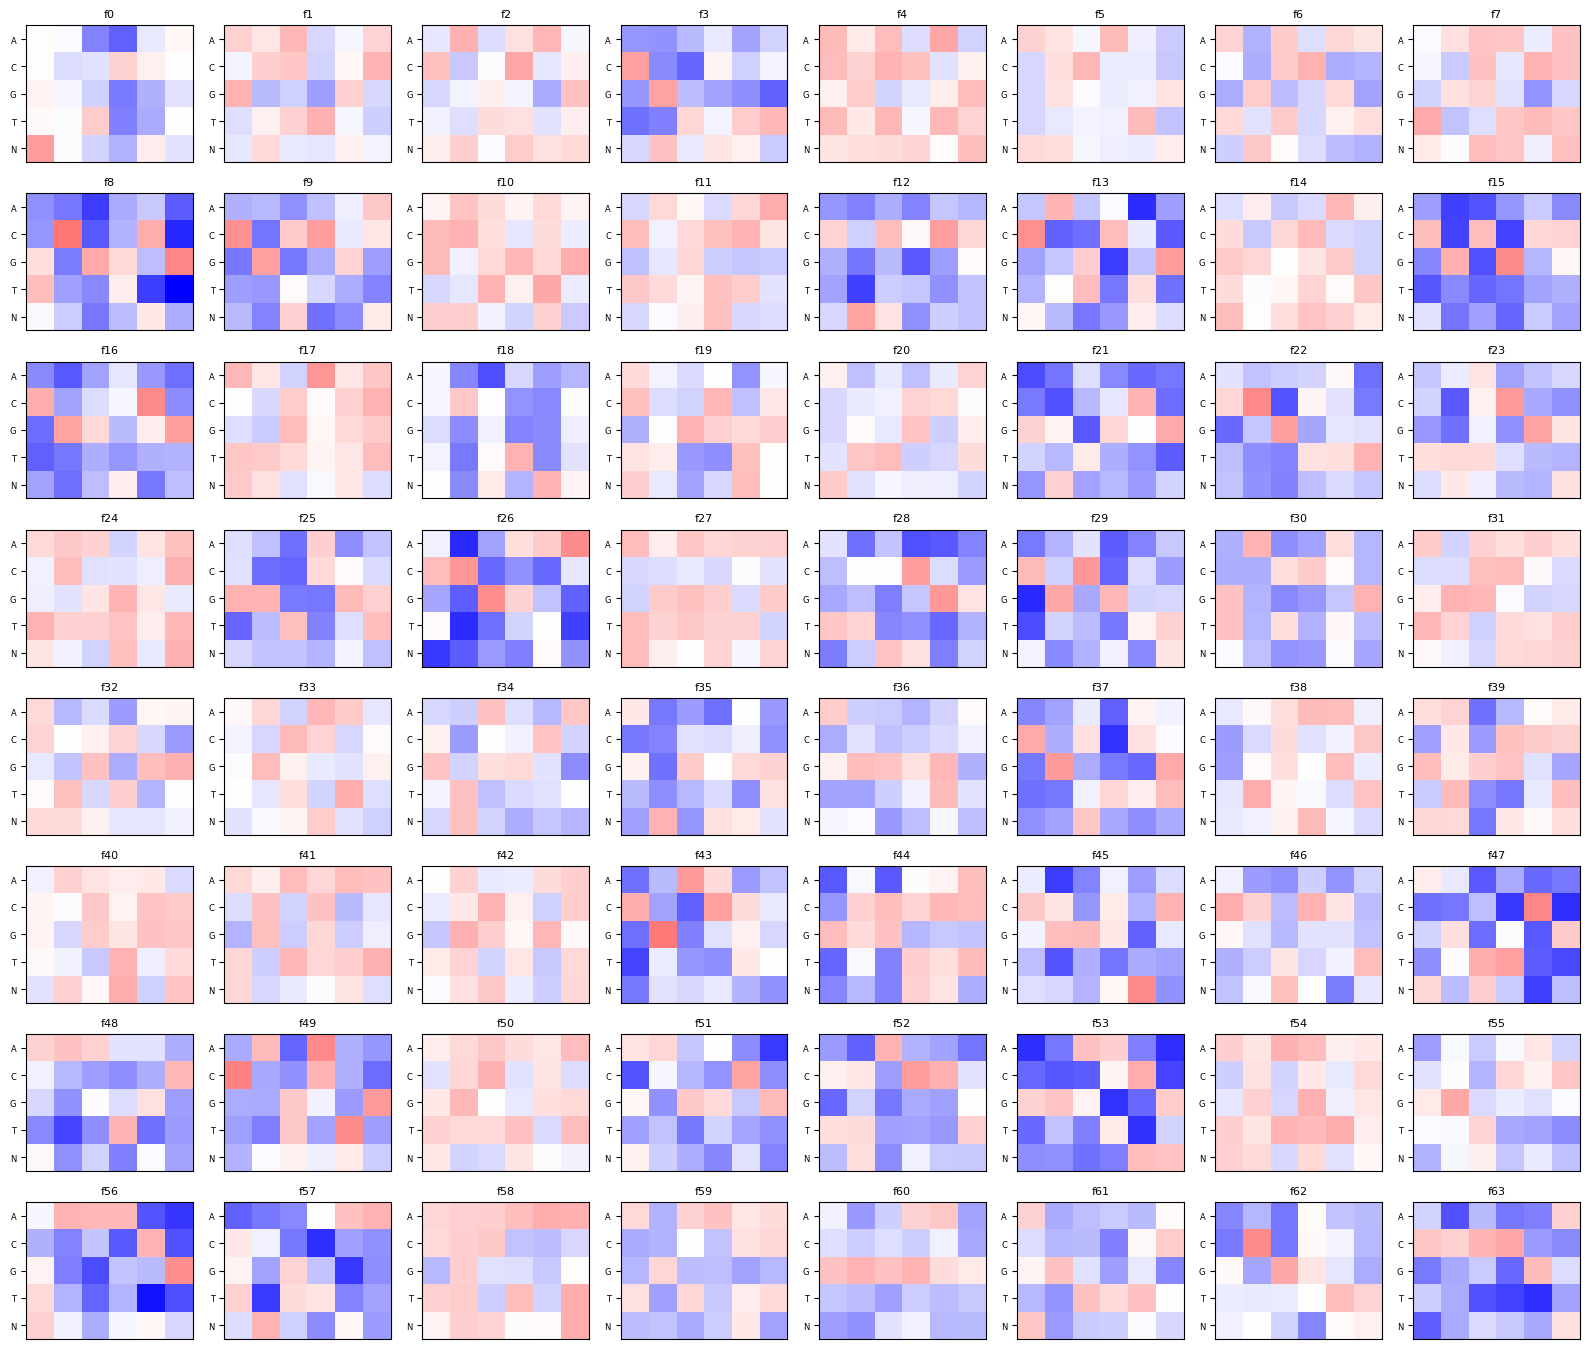


각 필터가 반응하는 패턴(각 위치에서 가중치 최대 염기):
  filter  0: NNTCNA
  filter  1: GCATGC
  filter  2: CATCAG
  filter  3: CGTNTT
  filter  4: TGCCAG
  filter  5: ACCATG
  filter  6: ANACAT
  filter  7: TGNACN
  filter  8: TCGGCG
  filter  9: CGCCGA
  filter 10: GCTGTG
  filter 11: CAGCCA
  filter 12: CNCCCC
  filter 13: CATCTG
  filter 14: NGCCAT
  filter 15: CGCGCC
  filter 16: CGGNCG
  filter 17: ATGACC
  filter 18: NCNTNN
  filter 19: CTGCNG
  filter 20: NTTGCA
  filter 21: GNTGCG
  filter 22: CCGTTT
  filter 23: TTTCGN
  filter 24: TCTGAC
  filter 25: GGTAGT
  filter 26: CCGGAA
  filter 27: NGGGTG
  filter 28: TTNCGG
  filter 29: CGCGTT
  filter 30: TATCAG
  filter 31: TGGCAT
  filter 32: CTGTGG
  filter 33: AGCATG
  filter 34: GNAGCA
  filter 35: ANGNGG
  filter 36: AGGGGA
  filter 37: CGNTCG
  filter 38: NTCNGT
  filter 39: GTGCCT
  filter 40: GNCNGN
  filter 41: NGTCAT
  filter 42: TGCTGC
  filter 43: CGACCT
  filter 44: GCCTCT
  filter 45: CGGGNC
  filter 46: CCNCCT
  filter 47: NGTTCG
  filt

In [17]:
#@title ▶️ [심화·실행만 하세요] 학습된 필터 분석 A — 가중치 시각화 - 각 필터가 어떤 염기에 얼마 만큼의 가중치를 두는지 확인 (히트맵)  { display-mode: "form" }
# 【방법 A】 학습된 Conv1D 커널 전부(64개) 들여다보기 (가중치 시각화)
import numpy as np
import matplotlib.pyplot as plt

BASES_LABEL = list("ACGTN")

w = model.layers[0].get_weights()[0]   # Conv1D 가중치, 모양 (6, 5, 64)
n = w.shape[2]
print("커널 가중치 모양:", w.shape, f" (글자수6, 채널5, 필터{n})")

vmax = np.abs(w).max()                  # 색 범위(±) 통일
ncols = 8
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 1.7 * nrows))
axes = axes.ravel()
for f in range(n):
    ax = axes[f]
    ax.imshow(w[:, :, f].T, cmap="bwr", vmin=-vmax, vmax=vmax, aspect="auto")  # 빨강=양수, 파랑=음수
    ax.set_title(f"f{f}", fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(BASES_LABEL, fontsize=6)
    ax.set_xticks([])
for f in range(n, len(axes)):
    axes[f].axis("off")
plt.tight_layout(); plt.show()

# 각 필터의 대략적 선호 패턴 = 글자위치마다 가중치가 가장 큰 염기 (64개 전부)
print("\n각 필터가 반응하는 패턴(각 위치에서 가중치 최대 염기):")
for f in range(n):
    pref = "".join(BASES_LABEL[j] for j in w[:, :, f].argmax(axis=1))
    print(f"  filter {f:2d}: {pref}")
print("\n→ 방법 A(가중치 argmax)는 거친 읽기임. N이 섞이거나 제각각이면 잡음에 가까움.")
print("  진짜 확인은 아래 방법 B로 할 것.")


In [18]:
#@title ▶️ [심화·실행만 하세요] 학습된 필터 분석 B — 염기서열 2000개 데이터를 사용해서 각 필터가 어떤 서열에 가장 강하게 반응하는지 확인  { display-mode: "form" }
# 【방법 B】 데이터에서 각 필터(64개 전부)가 가장 강하게 반응한 6-mer 모으기
# 실제 서열을 Conv1D 층에 통과시켜, 점수가 가장 높았던 자리의 진짜 6글자를 꺼냄.
import numpy as np
from collections import Counter

BASES_LABEL = list("ACGTN")
K = 6

# Conv1D 층의 출력(= 위치별 필터 점수)만 뽑는 미니 모델
# (학습된 Conv1D 층을 그대로 재사용 — Keras 3 에서도 안전한 방식)
_inp = tf.keras.Input(shape=(MAXLEN, len(BASES)))
feat_model = tf.keras.Model(_inp, model.layers[0](_inp))          # 출력 (N, 802, 64)

sample = x_val[:2000]                              # 검증셋 일부만 사용
acts = feat_model.predict(sample, verbose=0)      # (2000, 802, 64)
n = acts.shape[2]

def window_to_str(oh):
    """(6,5) 원-핫 조각 -> 문자열. 패딩(전부 0)인 자리는 '.' 로 표시"""
    s = ""
    for row in oh:
        s += "." if row.sum() == 0 else BASES_LABEL[int(row.argmax())]
    return s

# padding="same", kernel_size=6 이면 출력위치 p 는 입력 [p-2 : p+4] 를 본 결과(왼쪽 패딩 2칸)
OFFSET = 2

print(f"=== 방법 B: 필터 {n}개 전부, 가장 강하게 반응한 6-mer 상위5 ===\n")
for f in range(n):
    scores = acts[:, :, f]                        # (2000, 802)
    top = scores.ravel().argsort()[-40:][::-1]    # 점수 상위 40개 위치
    si, pi = np.unravel_index(top, scores.shape)
    kmers = []
    for s_i, p_i in zip(si, pi):
        start = p_i - OFFSET
        if 0 <= start and start + K <= sample.shape[1]:
            kmers.append(window_to_str(sample[s_i, start:start + K]))
    common = Counter(kmers).most_common(5)
    print(f"filter {f:2d}: {common}")

print("\n→ 상위 6-mer가 서로 비슷하게 모이면 그 필터가 그 패턴(모티프) 탐지기라는 근거임.")
print("  제각각이거나 N이 많으면 깔끔한 패턴 없음.")


=== 방법 B: 필터 64개 전부, 가장 강하게 반응한 6-mer 상위5 ===

filter  0: [('NTTCCA', 22), ('NTTCNA', 11), ('NNTCCA', 6), ('NATCNA', 1)]
filter  1: [('GCATGC', 40)]
filter  2: [('CATCAG', 40)]
filter  3: [('CGTCTT', 28), ('CGTNTT', 12)]
filter  4: [('TGCCAG', 40)]
filter  5: [('ACCATG', 40)]
filter  6: [('ANACAT', 40)]
filter  7: [('TGNACC', 17), ('TANACN', 11), ('TGNTCN', 7), ('TGNACN', 5)]
filter  8: [('TCGGCG', 29), ('TCGTCG', 11)]
filter  9: [('CGCCGA', 40)]
filter 10: [('GCTGTG', 40)]
filter 11: [('CAGCCA', 40)]
filter 12: [('CNCCCC', 40)]
filter 13: [('CATCTG', 40)]
filter 14: [('NGCCAT', 23), ('GGCCAT', 8), ('NGCNAT', 5), ('NGNCAT', 4)]
filter 15: [('CGCGCC', 40)]
filter 16: [('CGGCCG', 21), ('CGGNCG', 19)]
filter 17: [('ATGACC', 40)]
filter 18: [('CCTTNN', 12), ('CCNTNC', 8), ('ACTTNN', 7), ('NCCTNN', 3), ('CCNTNN', 2)]
filter 19: [('CTGCNG', 40)]
filter 20: [('NTTGCA', 40)]
filter 21: [('GGTGCG', 28), ('GNTGCG', 12)]
filter 22: [('CCGTTT', 40)]
filter 23: [('TTTCGG', 34), ('TTTCGN', 6)]
filte

필터 분석 — IC(정보량) 높을수록 '뾰족한=특이적' 필터, ★ = 도메인 의미 후보

  flt consensus    IC   GC%  알려진 모티프 매칭
★f60     GGGGAG  12.0    83  GC box(Sp1) (80%)
★f58     TTCTAT  11.4    19  TATA box (80%)
★f27     AGGGTG  11.4    67  GC box(Sp1) (80%)
★f24     TCTGAC  11.1    50  CRE/AP-1 (100%)
★f63     CCCCGG  11.1    95  GC-rich
★f41     TGTCAT  11.1    33  CRE/AP-1 (80%)
★f2      CATCAG  11.1    56  CRE/AP-1 (80%)
★f52     TTACCT  11.0    40  GATA (80%)
★f51     GAGGCG  10.6    76  GC box(Sp1) (80%)
★f9      CGCCGC  10.6    94  GC box(Sp1) (100%)
★f8      GCGGCG  10.5    93  GC box(Sp1) (100%)
★f16     CGGCCG  10.4    98  GC box(Sp1) (80%)
★f15     CGCGCC  10.3    98  CpG (100%)
★f30     TATCAG  10.2    44  GATA (100%)
★f20     ATTGCA  10.0    34  CAAT box (80%)
★f21     GGTGCG   9.7    84  GC box(Sp1) (80%)
★f38     ATCAGT   9.4    21  AT-rich
★f62     GCGCTT   9.2    56  CpG (80%)

★ 도메인 의미 후보 24개: ['f60=GC box(Sp1)', 'f58=TATA box', 'f27=GC box(Sp1)', 'f24=CRE/AP-1', 'f63=GC-rich', 'f41=CRE/AP-1', 'f2=

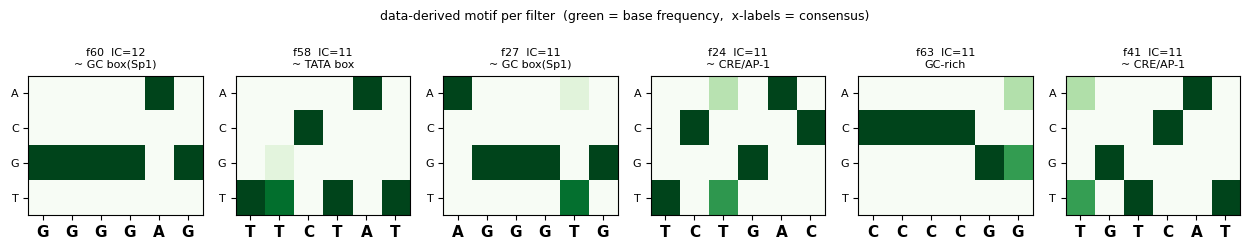


[더 해보기] 도메인 지식 없이 '분류에 중요한' 필터를 찾고 싶으면:
  세 클래스(enhancer/promoter/OCR)별 평균 활성차가 큰 필터를 추리면 됨 (기능적 중요도).


In [19]:
#@title ▶️ [심화·실행만 하세요] 학습된 필터 분석 C — 도메인 모티프 후보 추리기  { display-mode: "form" }
# 【방법 C】 64개 필터 중 '생물학적으로 의미 있어 보이는' 것만 추리기
#  - 방법 B처럼 데이터로 각 필터의 컨센서스(자주 반응한 패턴)를 만들고,
#  - 알려진 조절 모티프(TATA box·GC box 등)와 (정·역상보) 대조 + 정보량(IC, 특이성)으로 잡음 제거.
#  ※ 주의: '후보'일 뿐 확정 아님. 모델이 작고 학습마다 달라짐. 엄밀히는 JASPAR/TomTom 같은 DB 대조가 정석.
import numpy as np
import matplotlib.pyplot as plt

ACGT = "ACGT"; K = 6
OFFSET = 2                      # padding="same", kernel 6 → 출력위치 p 는 입력 [p-2 : p+4] 를 본 것
IC_THRESH = 3.0                 # 후보 기준(정보량). 낮추면 후보↑(잡음 섞임), 높이면 후보↓(확실한 것만)

# Conv1D 층 출력(위치별 필터 점수) 뽑는 미니 모델 (방법 B와 동일)
_inp = tf.keras.Input(shape=(MAXLEN, len(BASES)))
feat_model = tf.keras.Model(_inp, model.layers[0](_inp))
sample = x_val[:2000]
acts = feat_model.predict(sample, verbose=0)        # (2000, 802, 64)
n = acts.shape[2]; TOPN = 300

# 알려진 핵심 조절 모티프 (정방향 컨센서스; 역상보도 자동 대조)
KNOWN = {
    "TATA box":    "TATAAA",
    "CAAT box":    "CCAAT",
    "GC box(Sp1)": "GGGCGG",
    "E-box":       "CACGTG",
    "GATA":        "GATAA",
    "CRE/AP-1":    "TGACGT",
    "CpG":         "CGCGCG",
}
def _rc(s): return s.translate(str.maketrans("ACGT", "TGCA"))[::-1]
def best_motif(cons):                                # 컨센서스를 알려진 모티프와 슬라이딩 정렬해 최고 일치율
    best = ("-", 0.0)
    for nm, m in KNOWN.items():
        for mm in {m, _rc(m)}:
            for off in range(-len(mm) + 1, len(cons)):
                ov = mt = 0
                for k in range(len(mm)):
                    ci = off + k
                    if 0 <= ci < len(cons):
                        ov += 1
                        if mm[k] == cons[ci]: mt += 1
                if ov >= 4 and mt / ov > best[1]:
                    best = (nm, mt / ov)
    return best

def pwm_of(f, topn=TOPN):                            # 점수 상위 윈도우들로 데이터기반 빈도행렬(PWM)
    sc = acts[:, :, f].ravel()
    k = min(topn, sc.size)
    idx = np.argpartition(sc, -k)[-k:]
    si, pi = np.unravel_index(idx, acts.shape[:2])
    counts = np.zeros((K, 4))
    for s_i, p_i in zip(si, pi):
        st = p_i - OFFSET
        if st < 0 or st + K > sample.shape[1]: continue
        win = sample[s_i, st:st + K]
        if win.sum() < K * 0.6: continue             # 패딩 많은 윈도우 제외
        for j in range(K):
            b = int(np.argmax(win[j]))
            if win[j].sum() > 0 and b < 4: counts[j, b] += 1   # ACGT만(N·패딩 제외)
    return counts

rows = []
for f in range(n):
    c = pwm_of(f)
    tot = c.sum(axis=1, keepdims=True)
    freq = np.divide(c, tot, out=np.full_like(c, 0.25), where=tot > 0)
    ent = -np.nansum(np.where(freq > 0, freq * np.log2(freq), 0.0), axis=1)
    ic = float((2 - ent).sum())                      # 정보량(bits): 클수록 특이적(뾰족)
    cons = "".join(ACGT[int(freq[j].argmax())] for j in range(K))
    gc = float((freq[:, 1] + freq[:, 2]).mean() * 100)
    nm, score = best_motif(cons)
    if score >= 0.8:   label = nm
    elif gc >= 78:     label = "GC-rich"
    elif gc <= 22:     label = "AT-rich"
    else:              label = "-"
    cand = (ic >= IC_THRESH) and (label != "-")
    rows.append(dict(f=f, cons=cons, ic=ic, gc=gc, label=label, score=score, cand=cand, freq=freq))

rows.sort(key=lambda r: (not r["cand"], -r["ic"]))   # 후보 먼저, 그다음 IC 높은 순
print("필터 분석 — IC(정보량) 높을수록 '뾰족한=특이적' 필터, ★ = 도메인 의미 후보\n")
print(f"{'flt':>5} {'consensus':>9} {'IC':>5} {'GC%':>5}  알려진 모티프 매칭")
for r in rows[:18]:
    star = "★" if r["cand"] else " "
    mt = f"{r['label']} ({r['score']*100:.0f}%)" if r["score"] >= 0.8 else r["label"]
    print(f"{star}f{r['f']:<3} {r['cons']:>9} {r['ic']:5.1f} {r['gc']:5.0f}  {mt}")

cands = [r for r in rows if r["cand"]]
print(f"\n★ 도메인 의미 후보 {len(cands)}개:", [f"f{r['f']}={r['label']}" for r in cands][:12])
if not cands:
    print("이번 학습에선 알려진 모티프와 뚜렷이 매칭되는 필터가 적음 (재학습/IC_THRESH 조정 시 달라짐).")
print("※ 매칭%만 높고 IC가 낮으면 우연임 → IC(특이성)와 매칭을 함께 봐야 함.")

# 후보(없으면 IC 상위) PWM 시각화
show = (cands or rows)[:6]
fig, axes = plt.subplots(1, len(show), figsize=(2.1 * len(show), 2.5))
if len(show) == 1: axes = [axes]
for ax, r in zip(axes, show):
    ax.imshow(r["freq"].T, cmap="Greens", vmin=0, vmax=1, aspect="auto")
    ax.set_yticks(range(4)); ax.set_yticklabels(list(ACGT), fontsize=8)
    ax.set_xticks(range(K)); ax.set_xticklabels(list(r["cons"]), fontsize=11, fontweight="bold")
    ttl = f"f{r['f']}  IC={r['ic']:.0f}"
    if r["score"] >= 0.8:   ttl += f"\n~ {r['label']}"
    elif r["label"] != "-": ttl += f"\n{r['label']}"
    ax.set_title(ttl, fontsize=8)
fig.suptitle("data-derived motif per filter  (green = base frequency,  x-labels = consensus)", fontsize=9)
plt.tight_layout(); plt.show()

print("\n[더 해보기] 도메인 지식 없이 '분류에 중요한' 필터를 찾고 싶으면:")
print("  세 클래스(enhancer/promoter/OCR)별 평균 활성차가 큰 필터를 추리면 됨 (기능적 중요도).")


----------
## 7. 더 해보기 (성능 개선 아이디어)

직접 바꿔보면서 점수가 어떻게 달라지는지 실험해 볼 것!

**기본 튜닝**
- **`MAXLEN`** 을 바꿔보기 — 현재 802는 가장 긴 서열(802)까지 다 담는 무손실 값임.
줄이면(예: 400) 학습은 빨라지지만 그 길이를 넘는 서열은 뒤가 잘려 정보 손실이 생김 (이 데이터는 500에서 약 40%가 잘림)
- **필터 개수 / kernel_size** 조정 — 더 깊거나 넓은 돋보기
- **`epochs`** 늘리기 — 단, train만 좋아지고 validation이 나빠지면 **과적합** 신호
- **층을 더 쌓아보기** — 지금은 `Conv1D` 1개뿐. `Conv1D`+`MaxPooling1D` 를 여러 번 더 쌓고, 그 뒤에 완전연결층 FC +`Dropout`(0.2~0.5) / `BatchNormalization` 을 붙이면 표현력이 늘어남 (= 더 깊은 다층 CNN 으로 확장)

**강의자료에서 제안한 심화 (선택)**
- **Reverse complement augmentation**: 상보서열을 데이터 증강으로 추가
- **Embedding + 1D CNN**: 원-핫 대신 정수 토큰을 임베딩 후 Conv1D
- **Transformer** 로 확장